In [1]:
%pip install torch torchvision scikit-learn matplotlib pillow

  Using cached torch-2.10.0-cp314-cp314-win_amd64.whl.metadata (31 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 1.0/113.8 MB 6.1 MB/s eta 0:00:19
    --------------------------------------- 2.1/113.8 MB 5.9 MB/s eta 0:00:19
   - -------------------------------------- 3.4/113.8 MB 5.8 MB/s eta 0:00:19
   - -------------------------------------- 4.5/113.8 MB 5.8 MB/s eta 0:00:19
   - -------------------------------------- 5.5/113.8 MB 5.6 MB/s eta 0:00:20
   -- ------------------------------------- 5.8/113.8 MB 5.0 MB/s eta 0:00:22
   -- ------------------------------------- 6.6/113.8 MB 4.7 MB/s eta 0:00:23
   -- ------------------------------------- 7.6/113.8 MB 4.7 MB/s eta 0:00:23
   --- ----------------------------

In [ ]:
# MULTI-CANCER CLASSIFICATION

import os
import shutil
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image
import torchvision

random.seed(42)
torch.manual_seed(42)

# PATHS
SOURCE_DIR = "C:/Files/IISc/AI in Health Care/Multi Cancer/Multi Cancer/Input"
SELECTED_CANCER = "Brain Cancer"

DEST_DIR = r"C:/Files/IISc/AI in Health Care/Multi Cancer/Multi Cancer/data_split_brain"


# number of images per class (IMPORTANT SPEED CONTROL)
MAX_IMAGES_PER_CLASS = 5000

SPLITS = {"train": 0.7, "val": 0.15, "test": 0.15}
VALID_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# MODEL SAVE PATH
MODEL_DIR = "C:/Files/IISc/AI in Health Care/Multi Cancer/Multi Cancer/saved_model/brain"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "multi_cancer_densenet121_brain.pth")
META_PATH = os.path.join(MODEL_DIR, "model_metadata_brain.pth")

In [ ]:
# DATA SPLIT FUNCTION
def split_dataset():

    cancer_path = os.path.join(SOURCE_DIR, SELECTED_CANCER)

    if not os.path.exists(cancer_path):
        print(f"Cancer folder not found: {SELECTED_CANCER}")
        return

    if os.path.exists(DEST_DIR):
        print("Split already exists — skipping...")
        return

    print(f"\n Creating split for: {SELECTED_CANCER}\n")

    # iterate over subtype folders
    for subtype in os.listdir(cancer_path):

        subtype_path = os.path.join(cancer_path, subtype)

        if not os.path.isdir(subtype_path):
            continue

        print(f"\nProcessing subtype: {subtype}")

        # collect valid images
        images = [
            f for f in os.listdir(subtype_path)
            if f.lower().endswith(VALID_EXT)
        ]

        if len(images) == 0:
            print("⚠ No images found — skipping")
            continue

        # shuffle
        random.shuffle(images)

        # sample limit
        images = images[:MAX_IMAGES_PER_CLASS]

        n = len(images)

        train_end = int(n * SPLITS["train"])
        val_end = train_end + int(n * SPLITS["val"])

        split_map = {
            "train": images[:train_end],
            "val": images[train_end:val_end],
            "test": images[val_end:]
        }

        # copy files
        for split, files in split_map.items():

            dest_folder = os.path.join(
                DEST_DIR,
                split,
                subtype   # ✅ subtype becomes class label
            )

            os.makedirs(dest_folder, exist_ok=True)

            for f in files:
                shutil.copy2(
                    os.path.join(subtype_path, f),
                    os.path.join(dest_folder, f)
                )

            print(f"{split}: {len(files)} images")

    print("\nDataset split completed successfully!")

In [ ]:
# DATA LOADING
IMG_SIZE = 128          # smaller image
BATCH_SIZE = 16         # smaller batch

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.ImageFolder(
    f"{DEST_DIR}/train", transform=transform)

val_dataset = datasets.ImageFolder(
    f"{DEST_DIR}/val", transform=transform)

test_dataset = datasets.ImageFolder(
    f"{DEST_DIR}/test", transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Classes:", train_dataset.classes)



Classes: ['brain_glioma', 'brain_menin', 'brain_tumor']


In [ ]:
# MODEL — DenseNet121 

from torchvision.models import densenet121, DenseNet121_Weights

model = densenet121(weights=DenseNet121_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_classes = len(train_dataset.classes)

model.classifier = nn.Linear(
    model.classifier.in_features,
    num_classes
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# move model once
model = model.to(device)

In [ ]:
# TRAIN SETUP
criterion = nn.CrossEntropyLoss()

# Optimize only classifier (since backbone is frozen)
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

In [ ]:
# TRAINING LOOP
def train_model(epochs=10):

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f}")

# SAVE MODEL
def save_model():

    print("Saving trained model...")

    torch.save({
        "model_state_dict": model.state_dict(),
        "num_classes": num_classes,
        "class_to_idx": train_dataset.class_to_idx,
        "img_size": IMG_SIZE
    }, MODEL_PATH)

    print(f"Model saved at: {MODEL_PATH}")




In [6]:

train_model()
save_model()

c:\Files\IISc\AI in Health Care\Multi Cancer\Multi Cancer\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Loss: 279.1613
Epoch 2/10 | Loss: 206.6687
Epoch 3/10 | Loss: 183.4979
Epoch 4/10 | Loss: 181.7785
Epoch 5/10 | Loss: 174.8884
Epoch 6/10 | Loss: 164.2208
Epoch 7/10 | Loss: 158.8367
Epoch 8/10 | Loss: 162.5037
Epoch 9/10 | Loss: 162.4954
Epoch 10/10 | Loss: 162.5250
Saving trained model...
Model saved at: C:/Files/IISc/AI in Health Care/Multi Cancer/Multi Cancer/saved_model/brain\multi_cancer_densenet121_brain.pth


In [ ]:
# LOAD SAVED MODEL
def load_saved_model():

    print("Loading saved model...")

    checkpoint = torch.load(MODEL_PATH, map_location=device)

    from torchvision.models import densenet121

    loaded_model = densenet121(weights=None)

    loaded_model.classifier = nn.Linear(
        loaded_model.classifier.in_features,
        checkpoint["num_classes"]
    )

    loaded_model.load_state_dict(checkpoint["model_state_dict"])
    loaded_model = loaded_model.to(device)
    loaded_model.eval()

    class_to_idx = checkpoint["class_to_idx"]
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    print("Model loaded successfully!")

    return loaded_model, idx_to_class

In [6]:
def evaluate_saved_model(loader):

    loaded_model, idx_to_class = load_saved_model()

    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = loaded_model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    print(f"Accuracy: {acc:.4f}")
    return acc

In [7]:
evaluate_saved_model(val_loader)
evaluate_saved_model(test_loader)

Loading saved model...
Model loaded successfully!
Accuracy: 0.9076
Loading saved model...
Model loaded successfully!
Accuracy: 0.9222


0.9222222222222223

In [ ]:
# CLASS METADATA (Subclass + Description)

CLASS_INFO = {
    # "all_benign": ("Benign", "Non-cancerous, healthy cells"),
    # "all_early": ("Early", "Early stages of leukemia"),
    # "all_pre": ("Pre", "Pre-stage abnormal cells"),
    # "all_pro": ("Pro", "Advanced leukemia cells"),

    "brain_glioma": ("Glioma", "Most common brain tumor"),
    "brain_menin": ("Meningioma", "Tumors affecting brain membranes"),
    "brain_tumor": ("Pituitary Tumor", "Tumors affecting the pituitary gland"),

    # "breast_benign": ("Benign", "Non-cancerous breast tissues"),
    # "breast_malignant": ("Malignant", "Cancerous breast tissues"),

    # "cervix_dyk": ("Dyskeratotic", "Abnormal cell growth"),
    # "cervix_koc": ("Koilocytotic", "Cells showing viral infection changes (HPV)"),
    # "cervix_mep": ("Metaplastic", "Cells changed from one type to another (precancerous)"),
    # "cervix_pab": ("Parabasal", "Immature squamous cells"),
    # "cervix_sfi": ("Superficial-Intermediate", "More mature squamous cells"),

    # "kidney_normal": ("Normal", "Healthy kidney tissues"),
    # "kidney_tumor": ("Tumor", "Tumor-affected kidney tissues"),

    # "colon_aca": ("Colon Adenocarcinoma", "Cancerous cells of the colon"),
    # "colon_bnt": ("Colon Benign Tissue", "Healthy colon tissues"),

    # "lung_aca": ("Lung Adenocarcinoma", "Cancerous lung cells"),
    # "lung_bnt": ("Lung Benign Tissue", "Healthy lung tissues"),
    # "lung_scc": ("Lung Squamous Cell Carcinoma", "Aggressive lung cancer type"),

    # "lymph_cll": ("Chronic Lymphocytic Leukemia", "Slow-progressing blood cancer"),
    # "lymph_fl": ("Follicular Lymphoma", "Slow-growing non-Hodgkin lymphoma"),
    # "lymph_mcl": ("Mantle Cell Lymphoma", "Aggressive lymphoma"),

    # "oral_normal": ("Normal", "Healthy oral tissues"),
    # "oral_scc": ("Oral Squamous Cell Carcinoma", "Cancerous oral cells"),
}

In [ ]:
# TOP CANCER PREDICTION WITH PROBABILITIES

import torch.nn.functional as F


def predict_top3(image_path,use_saved=True):

    if use_saved:
        loaded_model, idx_to_class = load_saved_model()
    else:
        loaded_model = model
        idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

    img = Image.open(image_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    loaded_model.eval()

    with torch.no_grad():
        outputs = loaded_model(img)

        # Convert logits → probabilities
        probs = F.softmax(outputs, dim=1)[0]

        # Top 3 predictions
        top_probs, top_indices = torch.topk(probs, k=3)

    results = []

    print("\n==============================")
    print("   AI CANCER DIAGNOSIS REPORT")
    print("==============================\n")

    for rank, (prob, idx) in enumerate(zip(top_probs, top_indices), start=1):

        class_name = idx_to_class[idx.item()]

        subclass, description = CLASS_INFO.get(
            class_name,
            ("Unknown", "Description unavailable")
        )

        probability = prob.item() * 100

        result = {
            "rank": rank,
            "class": class_name,
            "subclass": subclass,
            "description": description,
            "probability": probability,
        }

        results.append(result)

        print(f"{rank}. Prediction: {class_name}")
        print(f"   Subclass   : {subclass}")
        print(f"   Probability: {probability:.2f}%")
        print(f"   Description: {description}")
        print()

    return results

In [10]:
predict_top3(
"C:/Files/IISc/AI in Health Care/Multi Cancer/brain_menin_0016.jpg",use_saved=True
)

Loading saved model...
Model loaded successfully!

   AI CANCER DIAGNOSIS REPORT

1. Prediction: brain_menin
   Subclass   : Meningioma
   Probability: 99.79%
   Description: Tumors affecting brain membranes

2. Prediction: brain_glioma
   Subclass   : Glioma
   Probability: 0.20%
   Description: Most common brain tumor

3. Prediction: brain_tumor
   Subclass   : Pituitary Tumor
   Probability: 0.01%
   Description: Tumors affecting the pituitary gland



[{'rank': 1,
  'class': 'brain_menin',
  'subclass': 'Meningioma',
  'description': 'Tumors affecting brain membranes',
  'probability': 99.78863596916199},
 {'rank': 2,
  'class': 'brain_glioma',
  'subclass': 'Glioma',
  'description': 'Most common brain tumor',
  'probability': 0.19774821121245623},
 {'rank': 3,
  'class': 'brain_tumor',
  'subclass': 'Pituitary Tumor',
  'description': 'Tumors affecting the pituitary gland',
  'probability': 0.013616833894047886}]

In [ ]:
# PURE PYTORCH GRAD-CAM (Python 3.14 SAFE)

import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F


class GradCAM:
    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        # forward hook
        target_layer.register_forward_hook(self.save_activation)

        # backward hook
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class):

        output = self.model(input_tensor)

        self.model.zero_grad()

        loss = output[:, target_class]
        loss.backward()

        # Global Average Pooling of gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().cpu().numpy()

        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam

In [ ]:
# GRAD-CAM VISUALIZATION (NO CAPTUM)

def predict_with_GradCAM(image_path, use_saved=True):

    print("\nGenerating Grad-CAM visualization...")

    # -------------------------------
    # Load model
    # -------------------------------
    if use_saved:
        loaded_model, idx_to_class = load_saved_model()
    else:
        loaded_model = model
        idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

    loaded_model.eval()

    # -------------------------------
    # Prepare image
    # -------------------------------
    img_pil = Image.open(image_path).convert("RGB")

    img = transform(img_pil).unsqueeze(0).to(device)
    img.requires_grad = True

    # -------------------------------
    # Prediction
    # -------------------------------
    outputs = loaded_model(img)
    pred_class = outputs.argmax(dim=1).item()

    class_name = idx_to_class[pred_class]

    print("Predicted Class:", class_name)

    # -------------------------------
    # DenseNet121 LAST CONV LAYER
    # -------------------------------
    target_layer = loaded_model.features.denseblock4

    gradcam = GradCAM(loaded_model, target_layer)

    heatmap = gradcam.generate(img, pred_class)

    # -------------------------------
    # Undo normalization
    # -------------------------------
    img_np = img.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    # -------------------------------
    # Overlay
    # -------------------------------
    plt.figure(figsize=(6,6))
    plt.imshow(img_np)
    plt.imshow(heatmap, cmap="jet", alpha=0.5)
    plt.title(f"Grad-CAM — {class_name}")
    plt.axis("off")
    plt.show()

    # Side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(10,5))

    axs[0].imshow(img_np)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    axs[1].imshow(img_np)
    axs[1].imshow(heatmap, cmap="jet", alpha=0.5)
    axs[1].set_title("Grad-CAM Heatmap")
    axs[1].axis("off")

    plt.show()


Generating Grad-CAM visualization...
Loading saved model...
Model loaded successfully!
Predicted Class: brain_tumor


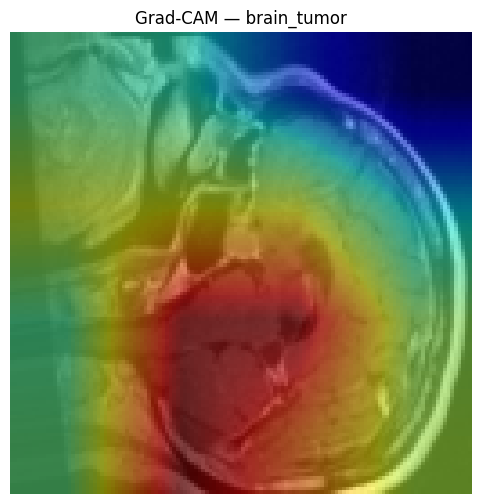

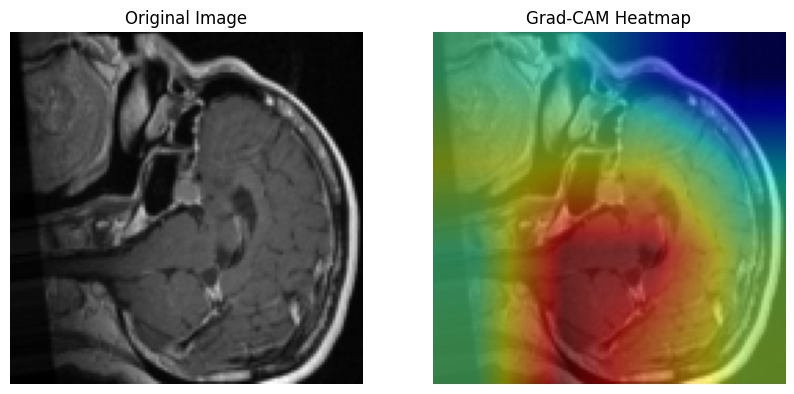

In [19]:
predict_with_GradCAM(
    "C:/Files/IISc/AI in Health Care/Multi Cancer/brain_tumor_0001.jpg",
    use_saved=True
)


Generating Grad-CAM visualization...
Loading saved model...
Model loaded successfully!
Predicted Class: brain_menin


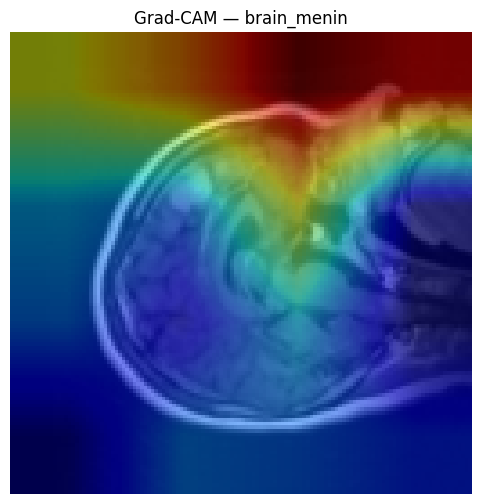

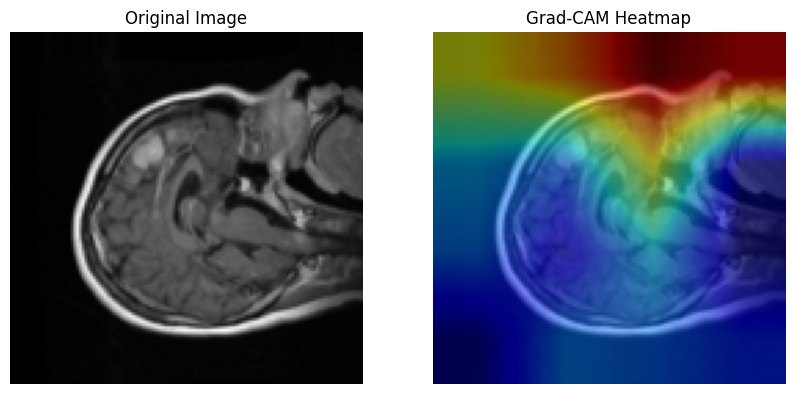

In [21]:
predict_with_GradCAM(
    "C:/Files/IISc/AI in Health Care/Multi Cancer/brain_menin_0001.jpg",
    use_saved=True
)


Generating Grad-CAM visualization...
Loading saved model...
Model loaded successfully!
Predicted Class: brain_tumor


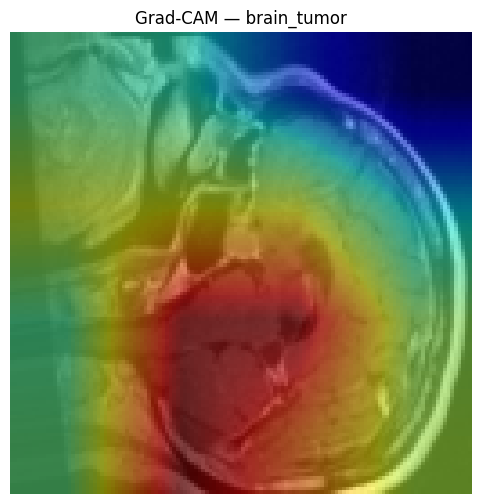

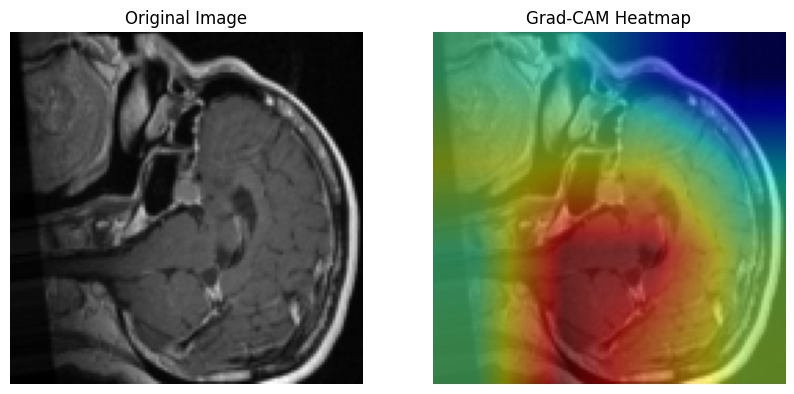

In [22]:
predict_with_GradCAM(
    "C:/Files/IISc/AI in Health Care/Multi Cancer/brain_tumor_0001.jpg",
    use_saved=True
)

In [ ]:
# PURE PYTORCH GRAD-CAM (CAPTUM FREE)

import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # register hooks
        self.forward_handle = target_layer.register_forward_hook(
            self._forward_hook
        )

        self.backward_handle = target_layer.register_full_backward_hook(
            self._backward_hook
        )

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):

        output = self.model(input_tensor)

        self.model.zero_grad()

        loss = output[:, class_idx]
        loss.backward()

        # Global Average Pooling on gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        cam = torch.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().cpu().numpy()

        # normalize heatmap
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

In [ ]:
# GRAD-CAM PREDICTION

def predict_with_gradcam(image_path, use_saved=True):

    if use_saved:
        model_gc, idx_to_class = load_saved_model()
    else:
        model_gc = model
        idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

    model_gc.eval()

    # load image
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Forward pass (gradients REQUIRED)
    outputs = model_gc(img_tensor)
    pred_class = outputs.argmax(dim=1).item()

    class_name = idx_to_class[pred_class]
    print("Predicted Class:", class_name)

    # DenseNet121 LAST CONV LAYER (correct one)
    target_layer = model_gc.features.denseblock4

    gradcam = GradCAM(model_gc, target_layer)

    heatmap = gradcam.generate(img_tensor, pred_class)

    gradcam.remove_hooks()

    # prepare image for plotting
    img_for_plot = img_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img_for_plot = (
        img_for_plot - img_for_plot.min()
    ) / (img_for_plot.max() - img_for_plot.min())

    return img_for_plot, heatmap, pred_class

In [ ]:
# GRAD-CAM + LIME VISUALIZATION

from lime import lime_image
from skimage.segmentation import mark_boundaries


def lime_explanation(image_np):

    explainer = lime_image.LimeImageExplainer()

    def predict_fn(images):
        images = torch.tensor(images).permute(0,3,1,2).float() / 255.0
        images = transforms.Normalize([0.5]*3,[0.5]*3)(images)
        images = images.to(device)

        loaded_model, _ = load_saved_model()
        loaded_model.eval()

        with torch.no_grad():
            outputs = loaded_model(images)
            probs = F.softmax(outputs, dim=1)

        return probs.cpu().numpy()

    explanation = explainer.explain_instance(
        image_np,
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    return mark_boundaries(temp / 255.0, mask)

c:\Files\IISc\AI in Health Care\Multi Cancer\Multi Cancer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading saved model...
Model loaded successfully!
Predicted Class: brain_tumor


  0%|          | 0/1000 [00:00<?, ?it/s]

Loading saved model...
Model loaded successfully!


  1%|          | 10/1000 [00:00<00:24, 41.18it/s]

Loading saved model...
Model loaded successfully!


...

Model loaded successfully!
Loading saved model...


 99%|█████████▉| 990/1000 [00:28<00:00, 34.39it/s]

Model loaded successfully!
Loading saved model...


100%|██████████| 1000/1000 [00:28<00:00, 34.67it/s]

Model loaded successfully!


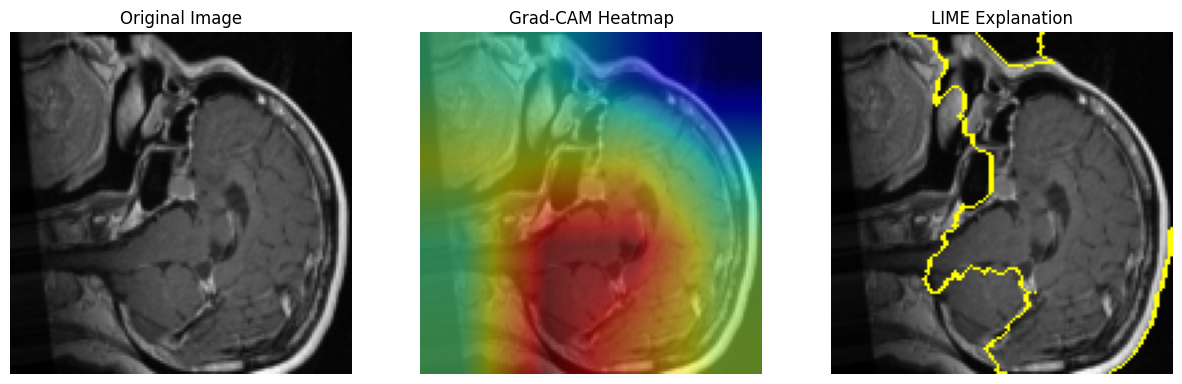

In [15]:
IMAGE_PATH = "C:/Files/IISc/AI in Health Care/Multi Cancer/brain_tumor_0001.jpg"

img_for_plot, gradcam_heatmap, pred_class = predict_with_gradcam(IMAGE_PATH)

test_image = (img_for_plot * 255).astype(np.uint8)
lime_output = lime_explanation(test_image)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(img_for_plot)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(img_for_plot)
axs[1].imshow(gradcam_heatmap, cmap="jet", alpha=0.5)
axs[1].set_title("Grad-CAM Heatmap")
axs[1].axis("off")

axs[2].imshow(lime_output)
axs[2].set_title("LIME Explanation")
axs[2].axis("off")

plt.show()

In [17]:
%pip install grad-cam

     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     ----- ---------------------------------- 1.0/7.8 MB 10.5 MB/s eta 0:00:01
     ---------- ----------------------------- 2.1/7.8 MB 5.2 MB/s eta 0:00:02
     ---------- ----------------------------- 2.1/7.8 MB 5.2 MB/s eta 0:00:02
     ----------------- ---------------------- 3.4/7.8 MB 4.1 MB/s eta 0:00:02
     --------------------- ------------------ 4.2/7.8 MB 4.3 MB/s eta 0:00:01
     ------------------------------ --------- 6.0/7.8 MB 4.9 MB/s eta 0:00:01
     ------------------------------------- -- 7.3/7.8 MB 5.4 MB/s eta 0:00:01
     ---------------------------------------- 7.8/7.8 MB 5.0 MB/s  0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finis

In [ ]:
# XAI: GRAD-CAM + LIME 

import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


# GRAD-CAM USING pytorch-grad-cam

def predict_with_Gradcam(image_path, use_saved=True):

    # load trained model
    if use_saved:
        loaded_model, idx_to_class = load_saved_model()
    else:
        loaded_model = model
        idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

    loaded_model.eval()

    # load image
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    # prediction
    with torch.no_grad():
        outputs = loaded_model(img_tensor)
        pred_class = outputs.argmax(dim=1).item()

    class_name = idx_to_class[pred_class]
    print("\nGrad-CAM Prediction:", class_name)

    # DenseNet121 final conv block
    target_layers = [loaded_model.features.denseblock4]

    cam = GradCAM(
        model=loaded_model,
        target_layers=target_layers
    )

    targets = [ClassifierOutputTarget(pred_class)]

    grayscale_cam = cam(
        input_tensor=img_tensor,
        targets=targets
    )

    gradcam_heatmap = grayscale_cam[0]

    # normalize heatmap
    gradcam_heatmap -= gradcam_heatmap.min()
    gradcam_heatmap /= (gradcam_heatmap.max() + 1e-8)

    img_for_plot = img_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img_for_plot = (
        img_for_plot - img_for_plot.min()
    ) / (img_for_plot.max() - img_for_plot.min())

    return img_for_plot, gradcam_heatmap, pred_class




In [ ]:
# LIME WRAPPER

def predict_fn(images):

    loaded_model, _ = load_saved_model()
    loaded_model.eval()

    batch = []

    for img in images:
        tensor = transform(
            Image.fromarray(img.astype(np.uint8))
        ).unsqueeze(0).to(device)

        batch.append(tensor)

    batch = torch.cat(batch, dim=0)

    with torch.no_grad():
        outputs = loaded_model(batch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()

    return probs


def lime_explanation(test_image):

    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        image=test_image,
        classifier_fn=predict_fn,
        top_labels=3,
        hide_color=0,
        num_samples=500
    )

    temp, mask = explanation.get_image_and_mask(
        label=explanation.top_labels[0],
        positive_only=True,
        hide_rest=False,
        num_features=1,
        min_weight=0
    )

    return mark_boundaries(temp, mask)




Loading saved model...
Model loaded successfully!

Grad-CAM Prediction: brain_tumor


  0%|          | 0/500 [00:00<?, ?it/s]

Loading saved model...
Model loaded successfully!


  2%|▏         | 10/500 [00:00<00:14, 33.48it/s]

Loading saved model...
Model loaded successfully!


...

Model loaded successfully!
Loading saved model...


 98%|█████████▊| 490/500 [00:15<00:00, 32.26it/s]

Model loaded successfully!
Loading saved model...


100%|██████████| 500/500 [00:15<00:00, 31.86it/s]

Model loaded successfully!


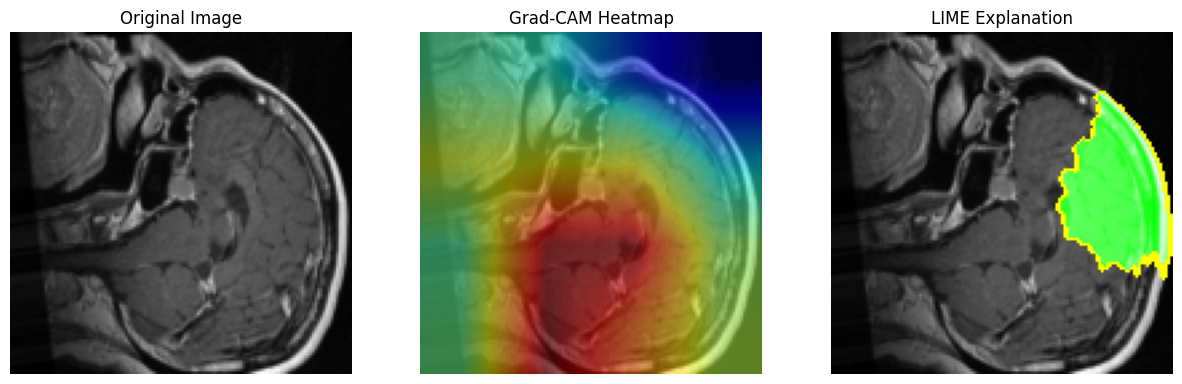

In [ ]:
# RUN XAI VISUALIZATION

IMAGE_PATH = \
"C:/Files/IISc/AI in Health Care/Multi Cancer/brain_tumor_0001.jpg"

img_for_plot, gradcam_heatmap, pred_class = \
    predict_with_Gradcam(IMAGE_PATH)

test_image = (img_for_plot * 255).astype(np.uint8)
lime_output = lime_explanation(test_image)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(img_for_plot)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(img_for_plot)
axs[1].imshow(gradcam_heatmap, cmap="jet", alpha=0.5)
axs[1].set_title("Grad-CAM Heatmap")
axs[1].axis("off")

axs[2].imshow(lime_output)
axs[2].set_title("LIME Explanation")
axs[2].axis("off")

plt.show()

In [ ]:
# # =====================================================
# # 7. PREDICTION
# # =====================================================
# def predict(image_path):

#     img = Image.open(image_path).convert("RGB")
#     img = transform(img).unsqueeze(0).to(device)

#     model.eval()
#     with torch.no_grad():
#         output = model(img)
#         _, pred = torch.max(output, 1)

#     return train_dataset.classes[pred.item()]

# print("Prediction:", predict("C:/Files/IISc/AI in Health Care/Multi Cancer/cervix_mep_5000.jpg"))

Prediction: cervix_mep
